# RL Group Project: Starter Notebook
## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity.

- In **Configuration A**, you will work with a tabular Sepsis MDP, where the state and action spaces are small enough to apply classical RL methods directly. 

- In **Configuration B**, you will move to a continuous-observation ICU environment that is clinically grounded and significantly more challenging. 

Three realistic failure modes are present in Configuration B, each reflecting a real scenario encountered in clinical AI deployments. The first is episodic observation noise, where monitoring equipment occasionally malfunctions. The second is episodic missing observations, representing situations where lab results are simply unavailable for an entire episode. The third is acute clinical events, which are sudden and irreversible patient deteriorations that occur independently of any treatment given.


---
### Group Members

Name of the Group: Group AG

```
Student 1: Beatriz Pinto
Student 2: Carlota Pires
Student 3: Francisca Calçoa
Student 4: Francisca Martins
Student 5: Marta Feital
```


## 0. Setup & Imports


In [1]:
# Install dependencies (run once)
#!pip install icu-sepsis numpy pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

SEED = 42
np.random.seed(SEED)

#  Import constants and env factory from env_setup.py 
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')


ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f'Required config: sofa_bias={SOFA_BIAS}, lam={LAM}')

Required config: sofa_bias=5.0, lam=0.02


---
## 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working with. The insights you gain here should inform your report's Methodology section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data. Each episode represents the trajectory of one ICU patient. The agent observes a discrete integer state (ranging from 0 to 715) and must select one of 25 treatment actions corresponding to combinations of vasopressor and IV fluid dose levels. The reward signal is sparse: **+1 at survival, 0 at death, and 0 for all intermediate steps**, with a discount factor γ = 1.


In [3]:
#  Instantiate and inspect the raw environment 
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f'Observation space : {env.observation_space} discrete integer state')
print(f'Action space      : {env.action_space}')
print(f'Initial state     : {obs}')
print()

#  Extract the full MDP model 
raw = env.unwrapped
P = raw._tx_mat    # shape (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                    # (716, 25, 716) — R[s, a, s']
R = (P * R_sasp).sum(axis=2)          # (716, 25)      — E[r | s, a]

print(f'Transition matrix P : {P.shape}  (S × A × S\')')
print(f'Reward matrix R     : {R.shape}  (S × A)')
print(f'Reward range        : [{R.min():.3f}, {R.max():.3f}]')
print()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S × A × S')
Reward matrix R     : (716, 25)  (S × A)
Reward range        : [-0.020, 0.708]



### Some conclusions about the environment:

**lam=0.02** is a small penalty applied to the reward when the agent gives unnecessary or excessive treatment (lambda).

**SOFA** is a clinical score measuring organ failure severity. The bias shifts the starting distributions of patients to be sicker on average. Our agent starts episodes with already ill patients.

**State = 716** means that we have 716 distinct discrete crinical states a patient can have and they are dervied by clustering the original 47 physiological variables (SOFA score, heart rate) into a finite set of clinical states.

**Action Space=25** is the 25 possible treatment conditions available to the agent.

**Initial State** is the patient's condition at the start of this particular episode.

**Transation Matrix P** gives for every state and ever action, and it tells us how likely a patient is to transition from one clinical state to another after a particular treatment is applied.

In [4]:
#  Random baseline: establish the performance floor 
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f'Random agent ({len(rand_returns)} episodes):')
print(f'  Mean return    : {np.mean(rand_returns):.4f}')
print(f'  Survival rate  : {survival_rate:.1f}%')
print(f'  Mean ep length : {np.mean(rand_lengths):.1f} steps')
print()
print('All Config A algorithms must beat the random baseline.')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random agent (1000 episodes):
  Mean return    : 0.5836
  Survival rate  : 68.9%
  Mean ep length : 10.6 steps

All Config A algorithms must beat the random baseline.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


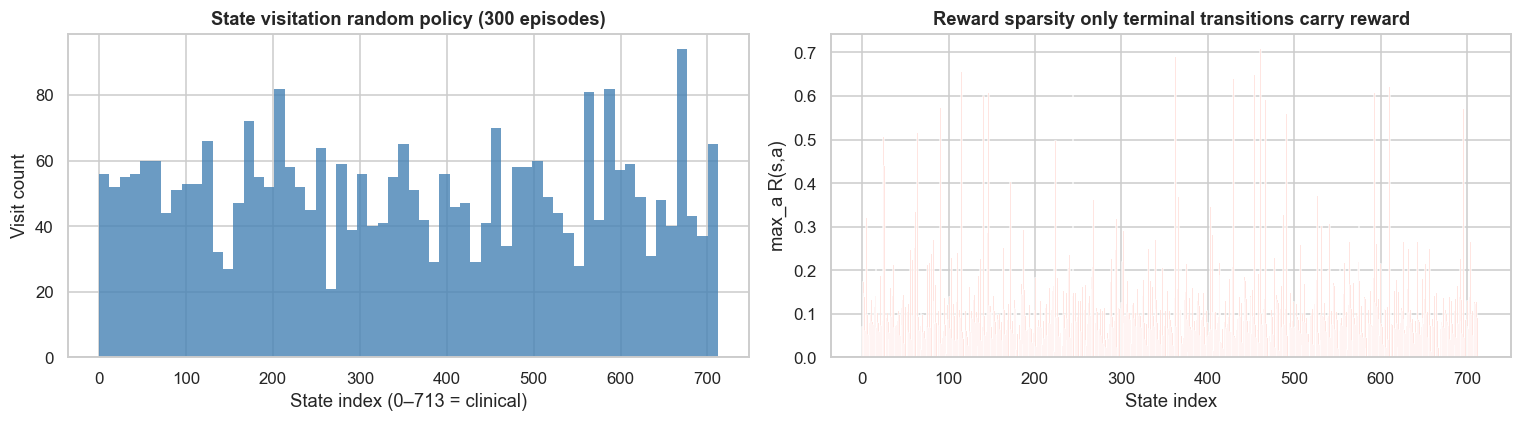

In [5]:
#  Visualise state visitation and reward structure 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('State index (0–713 = clinical)')
axes[0].set_ylabel('Visit count')
axes[0].set_title('State visitation random policy (300 episodes)', fontweight='bold')

# Max achievable reward per state (only survival-adjacent states have r > 0)
axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('max_a R(s,a)')
axes[1].set_title('Reward sparsity only terminal transitions carry reward',
                  fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_env_exploration.png', bbox_inches='tight')
plt.show()


---
# Config A — Tabular Methods

With 716 discrete states and 25 actions, the Q-table has shape `(716, 25)`, totalling 17,900 entries. This size is entirely manageable in memory, which is precisely what motivates the use of tabular algorithms here.


(array([9.490e+02, 1.218e+03, 2.139e+03, 2.818e+03, 2.465e+03, 1.865e+03,
        1.141e+03, 6.910e+02, 6.180e+02, 5.030e+02, 5.330e+02, 4.850e+02,
        4.230e+02, 2.820e+02, 1.550e+02, 2.660e+02, 1.950e+02, 1.640e+02,
        1.260e+02, 7.900e+01, 3.500e+01, 4.400e+01, 6.000e+01, 4.500e+01,
        2.500e+01, 4.700e+01, 2.900e+01, 3.000e+00, 2.100e+01, 1.000e+00,
        1.500e+01, 1.000e+01, 0.000e+00, 0.000e+00, 1.800e+01, 4.100e+01,
        1.600e+01, 0.000e+00, 1.000e+01, 4.900e+01, 2.200e+01, 4.000e+01,
        5.600e+01, 4.500e+01, 3.200e+01, 5.700e+01, 1.400e+01, 1.000e+01,
        2.100e+01, 1.900e+01]),
 array([-0.02      , -0.00544838,  0.00910325,  0.02365487,  0.0382065 ,
         0.05275812,  0.06730975,  0.08186137,  0.096413  ,  0.11096462,
         0.12551625,  0.14006787,  0.15461949,  0.16917112,  0.18372274,
         0.19827437,  0.21282599,  0.22737762,  0.24192924,  0.25648087,
         0.27103249,  0.28558412,  0.30013574,  0.31468736,  0.32923899,
         0.

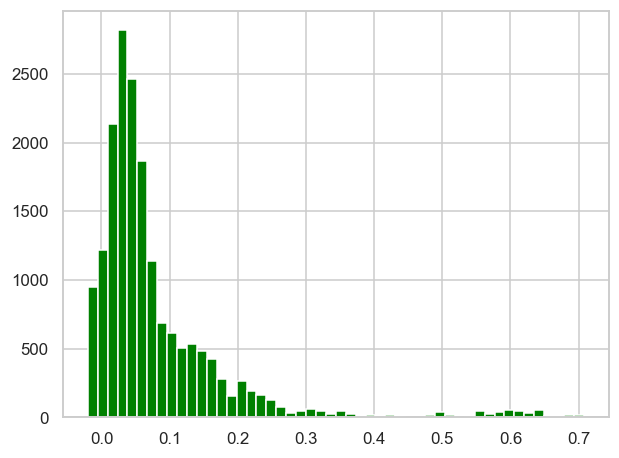

In [18]:
plt.hist(R.flatten(), bins=50, color='green')

The reward distribution is highly skewed, with most state action pairs yielding low or near zero reward. Only a small fraction of transitions correspond to high reward outcomes, representing clinically effective treatments in specific patient states. This reflects the sparse nature of clinical decision-making, where only targeted interventions significantly improve patient outcomes.

## Algorithm 1: Policy Iteration & Value Iteration

Both algorithms use the **known MDP model** (transition matrix P and reward matrix R) extracted directly from the environment. They are guaranteed to converge to the **optimal policy π\* and value function V\***.

| Property | Policy Iteration | Value Iteration |
|---|---|---|
| Update target | π then V | V only (π extracted at end) |
| Inner loop | Policy evaluation (iterate to convergence) | Bellman optimality backup |
| Convergence | Finite outer iterations | Asymptotic (θ threshold) |
| Per-iteration cost | Heavier (matrix-vector until eval convergence) | Lighter (single sweep) |


## A.1 Policy Iteration

Policy Iteration alternates between two steps until the policy stops changing:

1. **Policy Evaluation**: here we assume that we have a fixed action/policy for each state and evaluate how good it is

2. **Policy Improvement**: knowing the value of each state, we ask if there's a better action for that state

Convergence is guaranteed in a finite number of outer loops because the policy can only improve (monotone improvement theorem) and there are finitely many deterministic policies.

In [7]:
# Policy Iteration 

def policy_iteration(P, R, gamma=1.0, theta=1e-8, max_iter=1000):
    """
    Policy Iteration on a tabular MDP with known model.

    Parameters
    ----------
    P     : ndarray (S, A, S') - transition probabilities P[s,a,s']
    R     : ndarray (S, A)     - expected reward E[r | s, a]
    gamma : float              - discount factor
    theta : float              - convergence threshold for policy evaluation
    max_iter : int             - maximum outer (policy improvement) iterations

    Returns
    -------
    V      : ndarray (S,)  - optimal value function
    policy : ndarray (S,)  - optimal deterministic policy
    info   : dict          - convergence diagnostics
    """
    S, A, _ = P.shape

    # Initialise: arbitrary deterministic policy (action 0 everywhere)
    policy = np.zeros(S, dtype=int)
    V      = np.zeros(S)

    history = []     # max |Q*(s) - V(s)| per outer iteration
    n_iter  = 0

    for iteration in range(max_iter):
        n_iter += 1

        # Policy Evaluation 
        # P_pi[s, s'] = P[s, policy[s], s']   (S×S  transition under π)
        # R_pi[s]     = R[s, policy[s]]        (S    reward under π)
        P_pi = P[np.arange(S), policy, :]     # shape (S, S)
        R_pi = R[np.arange(S), policy]        # shape (S,)

        eval_delta = float('inf')
        while eval_delta > theta:
            V_new      = R_pi + gamma * P_pi.dot(V)
            eval_delta = float(np.max(np.abs(V_new - V)))
            V          = V_new

        # Policy Improvement 
        # Q[s, a] = R[s, a] + γ Σ_{s'} P[s,a,s'] V[s']
        Q          = R + gamma * P.dot(V)      # (S, A)
        new_policy = Q.argmax(axis=1)          # greedy improvement

        max_delta = float(np.max(np.abs(Q.max(axis=1) - V)))
        history.append(max_delta)

        # Convergence: policy unchanged
        if np.all(new_policy == policy):
            policy = new_policy
            break
        policy = new_policy

    return V, policy, {'n_iter': n_iter, 'history': history}


import time
print("Running Policy Iteration...")
t0 = time.time()
V_pi, policy_pi, info_pi = policy_iteration(P, R, gamma=GAMMA)
elapsed_pi = time.time() - t0

print(f"  Converged in {info_pi['n_iter']} outer iterations  ({elapsed_pi:.2f}s)")
print(f"  V* range  : [{V_pi.min():.4f}, {V_pi.max():.4f}]")
print(f"  Mean V*   : {V_pi.mean():.4f}")
print(f"  Unique actions in pi*: {len(np.unique(policy_pi))}")


Running Policy Iteration...
  Converged in 4 outer iterations  (0.11s)
  V* range  : [0.0000, 0.9814]
  Mean V*   : 0.8249
  Unique actions in pi*: 15


### Some Conclusions about PI:

- The algorithm converged in **4 outer iterations**, indicating very fast convergence of the policy evaluation/improvement loop.
- Total runtime was **0.11 seconds**, showing that the tabular MDP solution is computationally efficient for this state/action space.

- The optimal state-value function range suggests a bounded reward structure, where states vary from very poor outcomes (near 0) to highly favorable outcomes (close to 1).

- The **mean value** of \(V^*\) is **0.8249**, indicating that under the optimal policy, most states correspond to relatively good expected outcomes.

- The optimal policy uses **15 out of 25 possible actions**, meaning:
  - The agent does not rely on all treatments.
  - It selects a subset of clinically relevant or high-value interventions.
  - This suggests the policy has learned to ignore suboptimal or unnecessary actions.

Overall, the results show a stable and well-converged optimal policy with meaningful structure in both state values and action selection.

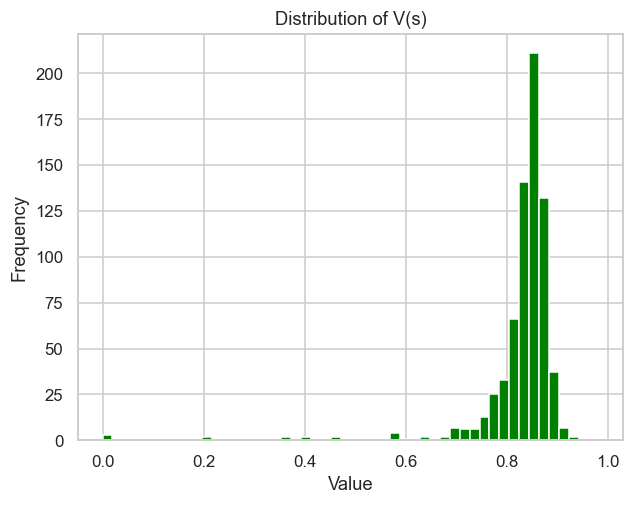

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(V_pi, bins=50, color='green')
plt.title("Distribution of V(s)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

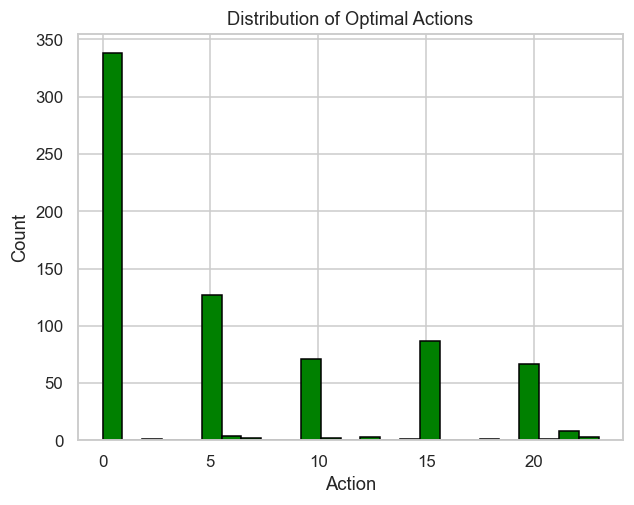

In [13]:
plt.figure()
plt.hist(policy_pi, bins=25, color='green', edgecolor='black')
plt.title("Distribution of Optimal Actions")
plt.xlabel("Action")
plt.ylabel("Count")
plt.show()

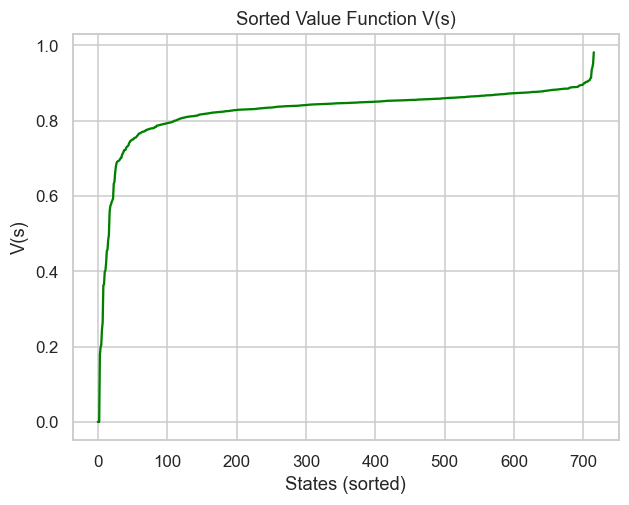

In [14]:
plt.figure()
plt.plot(sorted(V_pi), color='green')
plt.title("Sorted Value Function V(s)")
plt.xlabel("States (sorted)")
plt.ylabel("V(s)")
plt.show()

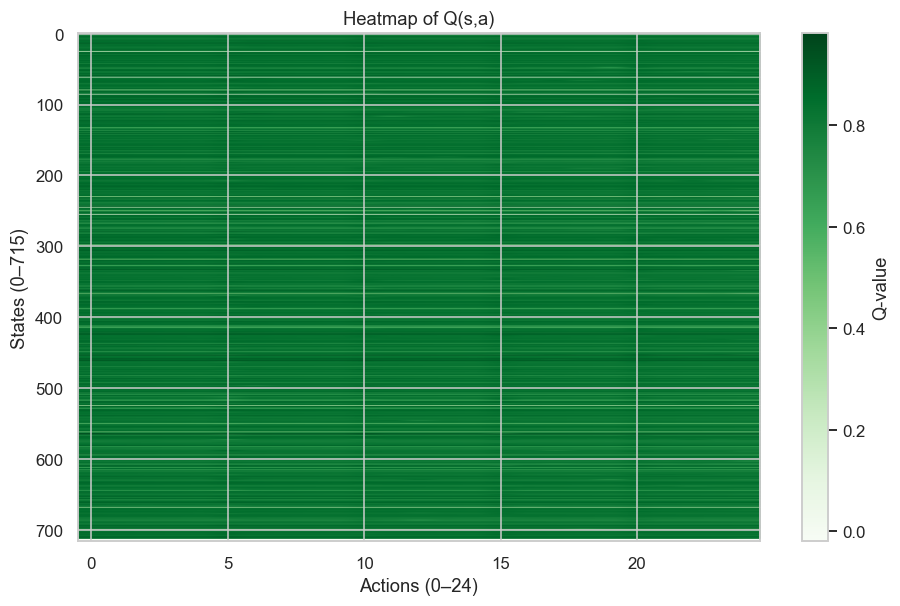

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Compute Q(s,a)
Q = R + GAMMA * P.dot(V_pi)   # (716, 25)

plt.figure(figsize=(10, 6))
plt.imshow(Q, aspect='auto', cmap='Greens')
plt.title("Heatmap of Q(s,a)")
plt.xlabel("Actions (0–24)")
plt.ylabel("States (0–715)")
plt.colorbar(label="Q-value")
plt.show()

## A.2 Value Iteration

Value Iteration applies the **Bellman optimality operator** repeatedly.


The policy is extracted greedily from the converged V. Each sweep is cheaper than a Policy Iteration outer loop (no inner evaluation loop), but more sweeps are typically required to reach the same precision.

In [8]:
# Value Iteration 

def value_iteration(P, R, gamma=1.0, theta=1e-8, max_iter=10_000):
    """
    Value Iteration on a tabular MDP with known model.

    Parameters
    ----------
    P     : ndarray (S, A, S') - transition probabilities P[s,a,s']
    R     : ndarray (S, A)     - expected reward E[r | s, a]
    gamma : float              - discount factor
    theta : float              - convergence threshold (max |DeltaV|)
    max_iter : int             - safety cap on sweeps

    Returns
    -------
    V      : ndarray (S,)  - optimal value function
    policy : ndarray (S,)  - greedy policy w.r.t. V
    info   : dict          - convergence diagnostics
    """
    S, A, _ = P.shape
    V       = np.zeros(S)      # initialise V arbitrarily (zeros)
    history = []               # max |DeltaV| per sweep
    Q       = np.zeros((S, A)) # will hold final Q-values

    for k in range(max_iter):
        # Bellman optimality backup: Q[s,a] = R[s,a] + gamma * sum_s' P[s,a,s'] V[s']
        Q     = R + gamma * P.dot(V)     # (S, A)
        V_new = Q.max(axis=1)            # (S,)  — max over actions
        # V_new is the best within all of the Q-values for each state
        delta = float(np.max(np.abs(V_new - V)))
        history.append(delta)
        V = V_new

        if delta < theta:
            break
    # policy = at the end what is the best treatment for each state
    policy = Q.argmax(axis=1)            # greedy policy extraction
    return V, policy, {'n_iter': k + 1, 'history': history}


print("Running Value Iteration...")
t0 = time.time()
V_vi, policy_vi, info_vi = value_iteration(P, R, gamma=GAMMA)
elapsed_vi = time.time() - t0

print(f"  Converged in {info_vi['n_iter']} sweeps  ({elapsed_vi:.2f}s)")
print(f"  V* range  : [{V_vi.min():.4f}, {V_vi.max():.4f}]")
print(f"  Mean V*   : {V_vi.mean():.4f}")
print(f"  Unique actions in pi*: {len(np.unique(policy_vi))}")


Running Value Iteration...
  Converged in 187 sweeps  (1.53s)
  V* range  : [0.0000, 0.9814]
  Mean V*   : 0.8249
  Unique actions in pi*: 15


### Conclusion

The algorithm needed 187 turns to stabilize and it took 1.47 seconds. The range of V* means that there's some states where the patient already died, even with the best treatment possible. The 0.9814 means that the best state possible has 98,14% of survived with an optimal treatment. 

In mean, if a patient shows in a random state and the doctor acts in an optimal way, the probability of surviving is 82.49% (more than the Random).

Out of 25 possible treatments, the optimal policy only uses 15.
This means that 10 treatments are never the best choice for any of the 716 patient states. The algorithm figured out on its own that those 10 treatments are always beaten by some other alternative.

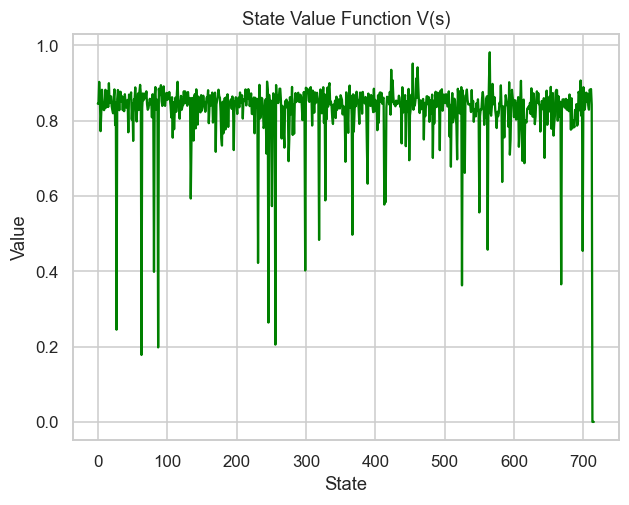

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(V_vi, color='green')
plt.title("State Value Function V(s)")
plt.xlabel("State")
plt.ylabel("Value")
plt.show()

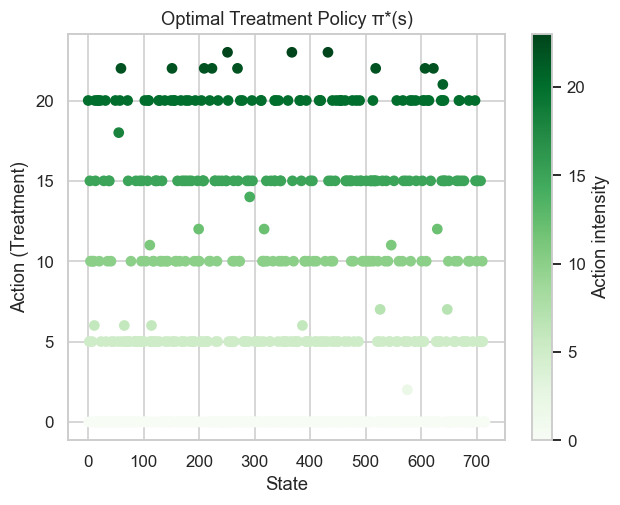

In [23]:
plt.figure()
plt.scatter(range(len(policy_vi)), policy_vi, c=policy_vi, cmap='Greens')
plt.title("Optimal Treatment Policy π*(s)")
plt.xlabel("State")
plt.ylabel("Action (Treatment)")
plt.colorbar(label="Action intensity")
plt.show()

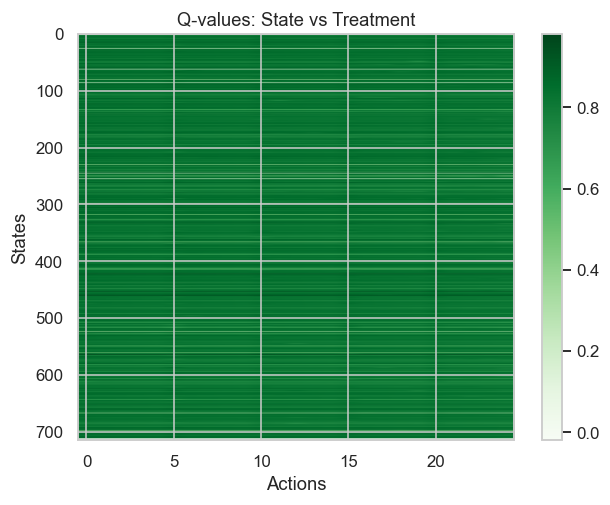

In [ ]:
plt.figure()
plt.imshow(Q, aspect='auto', cmap='Greens')
plt.title("Q-values: State vs Treatment")
plt.xlabel("Actions")
plt.ylabel("States")
plt.colorbar()
plt.show()

## Live Evaluation & Comparison

We roll out both policies on 1 000 live episodes and compare:

- **Survival rate** (mean return, since rewards are 0/1)
- **Episode length** (average steps before terminal state)
- **Value-function agreement** between the two algorithms
- **Convergence speed** (iterations and wall time)
- **Policy agreement** (fraction of states where both algorithms prescribe the same action)

In [ ]:
# Evaluation 

def evaluate_policy(policy, n_episodes=1000, seed=SEED):
    """Roll out a deterministic tabular policy for n_episodes."""
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000)) # here is where the enviroments is creating randomly live episodes
        total_r, steps, done = 0.0, 0, False
        while not done:
            action = int(policy[int(obs)])
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


print("Evaluating Policy Iteration policy  (1 000 episodes)...")
ret_pi, len_pi = evaluate_policy(policy_pi)

print("Evaluating Value Iteration policy   (1 000 episodes)...")
ret_vi, len_vi = evaluate_policy(policy_vi)

# Summary table 
results = pd.DataFrame({
    "Method"         : ["Random Baseline", "Policy Iteration", "Value Iteration"],
    "Survival Rate"  : [
        f"{float(np.mean(rand_returns > 0)) * 100:.1f}%",
        f"{float(np.mean(ret_pi  > 0)) * 100:.1f}%",
        f"{float(np.mean(ret_vi  > 0)) * 100:.1f}%",
    ],
    "Mean Return"    : [
        f"{np.mean(rand_returns):.4f}",
        f"{np.mean(ret_pi):.4f}",
        f"{np.mean(ret_vi):.4f}",
    ],
    "Mean Ep Length" : [
        f"{np.mean(rand_lengths):.1f}",
        f"{np.mean(len_pi):.1f}",
        f"{np.mean(len_vi):.1f}",
    ],
    "Iterations"     : ["—", str(info_pi['n_iter']), str(info_vi['n_iter'])],
    "Wall Time (s)"  : ["—", f"{elapsed_pi:.2f}", f"{elapsed_vi:.2f}"],
})

print()
print(results.to_string(index=False))


Evaluating Policy Iteration policy  (1 000 episodes)...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Evaluating Value Iteration policy   (1 000 episodes)...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

          Method Survival Rate Mean Return Mean Ep Length Iterations Wall Time (s)
 Random Baseline         68.1%      0.5794           10.2          —             —
Policy Iteration         78.8%      0.7507            9.8          4          0.41
 Value Iteration         78.8%      0.7507            9.8        187          1.47


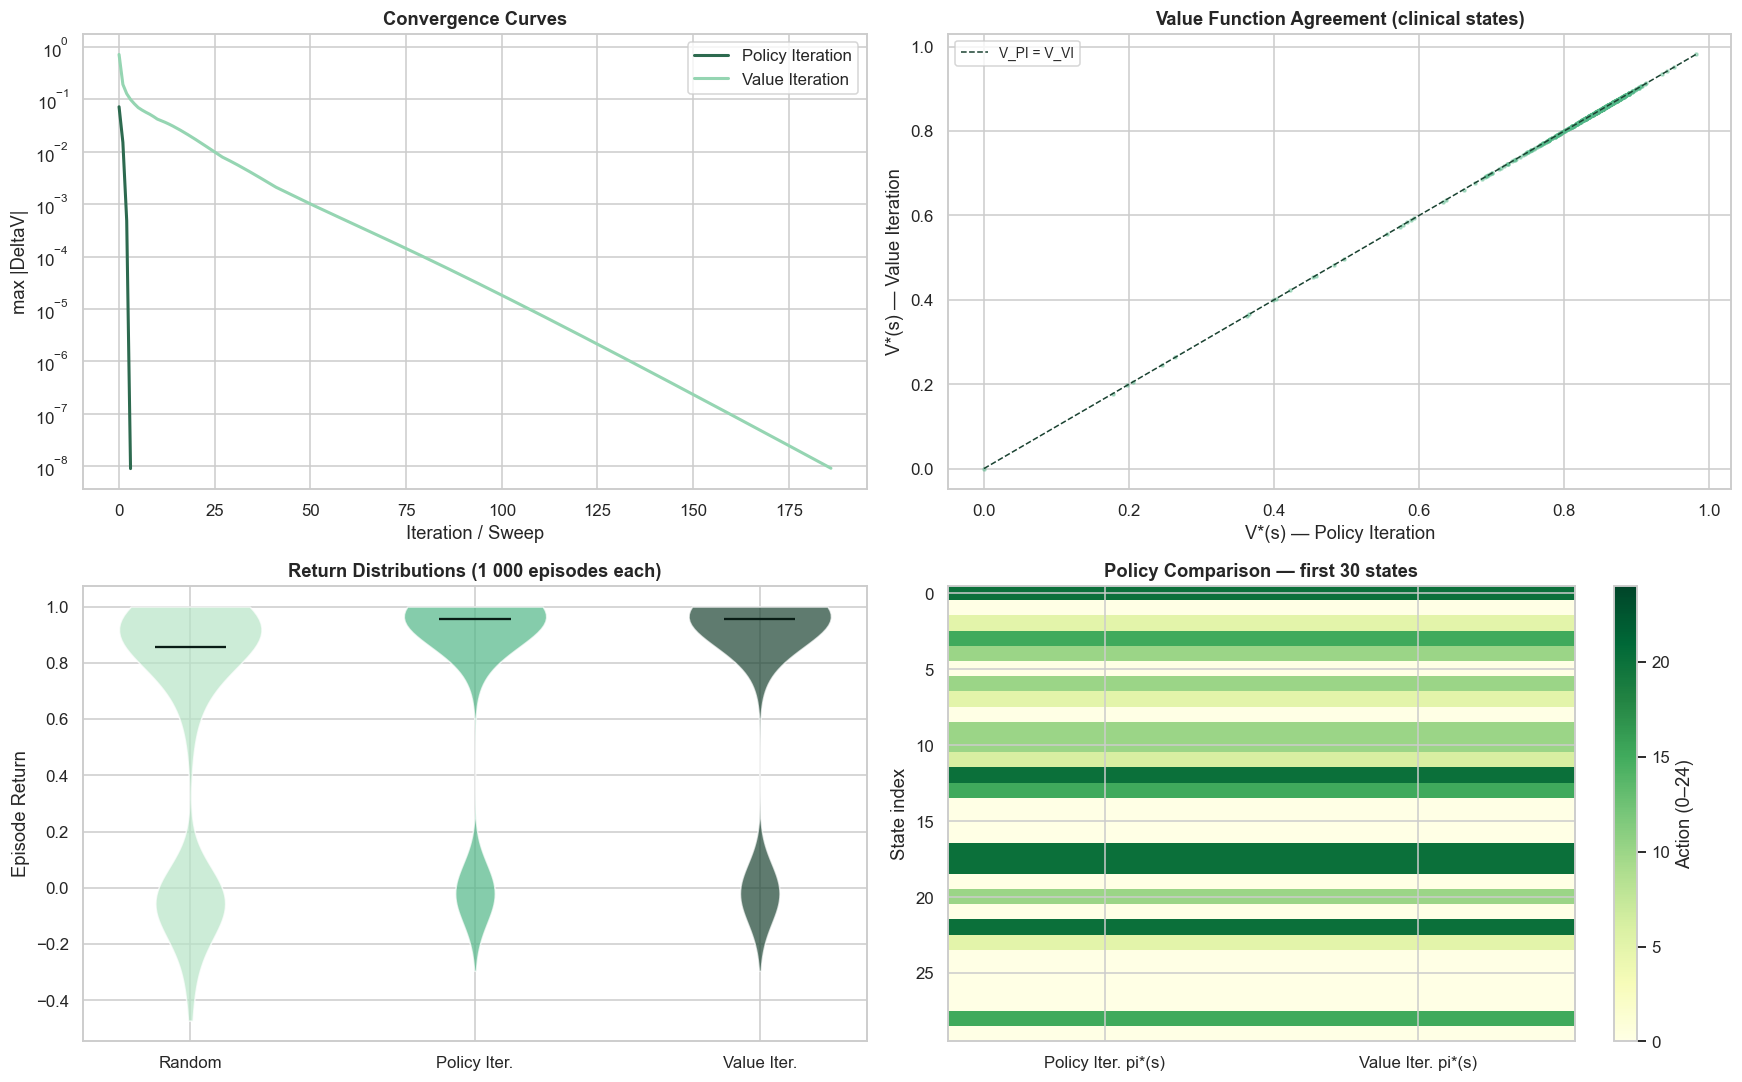


Policy agreement   : 100.0% of states
Max |V_PI - V_VI|  : 2.89e-08  (should be ~0 if both converged to V*)


In [ ]:
# Plots 

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Convergence curves
ax = axes[0, 0]
ax.plot(info_pi['history'], color='#2d6a4f',  label='Policy Iteration', linewidth=2)
ax.plot(info_vi['history'], color='#95d5b2', label='Value Iteration',  linewidth=2)
ax.set_yscale('log')
ax.set_xlabel('Iteration / Sweep')
ax.set_ylabel('max |DeltaV|')
ax.set_title('Convergence Curves', fontweight='bold')
ax.legend()

# Value function scatter: PI vs VI
ax = axes[0, 1]
clinical_states = [s for s in range(N_STATES) if s not in (STATE_SURVIVED, STATE_DIED)]
ax.scatter(V_pi[clinical_states], V_vi[clinical_states], s=4, alpha=0.4, color='#52b788')
lims = [min(V_pi.min(), V_vi.min()), max(V_pi.max(), V_vi.max())]
ax.plot(lims, lims, color='#1b4332', linestyle='--', linewidth=1, label='V_PI = V_VI')
ax.set_xlabel("V*(s) — Policy Iteration")
ax.set_ylabel("V*(s) — Value Iteration")
ax.set_title("Value Function Agreement (clinical states)", fontweight='bold')
ax.legend(fontsize=9)

# Return distributions (violin)
ax = axes[1, 0]
data_for_violin = [rand_returns, ret_pi, ret_vi]
labels = ['Random', 'Policy Iter.', 'Value Iter.']
colors = ['#b7e4c7', '#52b788', '#1b4332']   
parts  = ax.violinplot(data_for_violin, positions=range(3),
                       showmedians=True, showextrema=False)
for pc, col in zip(parts['bodies'], colors):
    pc.set_facecolor(col); pc.set_alpha(0.7)
parts['cmedians'].set_color('#081c15')
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_ylabel('Episode Return')
ax.set_title('Return Distributions (1 000 episodes each)', fontweight='bold')

# Policy side-by-side heatmap (first 30 clinical states)
ax = axes[1, 1]
n_show = 30
policy_grid = np.column_stack([policy_pi[:n_show], policy_vi[:n_show]])
im = ax.imshow(policy_grid, aspect='auto', cmap='YlGn', vmin=0, vmax=N_ACTIONS - 1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Policy Iter. pi*(s)", "Value Iter. pi*(s)"])
ax.set_ylabel('State index')
ax.set_title(f'Policy Comparison — first {n_show} states', fontweight='bold')
plt.colorbar(im, ax=ax, label='Action (0–24)')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_pi_vi_comparison.png', bbox_inches='tight')
plt.show()

# Policy & value agreement summary 
agree_rate = float(np.mean(policy_pi == policy_vi)) * 100
V_max_diff = float(np.max(np.abs(V_pi - V_vi)))
print(f"\nPolicy agreement   : {agree_rate:.1f}% of states")
print(f"Max |V_PI - V_VI|  : {V_max_diff:.2e}  (should be ~0 if both converged to V*)")

### Some conclusions about the graphs

- As we can see from Graph 1, the policy iteration converged really fast.
- Regarding the Value Function Agreement, both algorithms got the same results for every 716 states.
- Both PI and VI agree on 100% of states, as we can see from Policy Comparion graph, since the colours are always the same for both PI and VI.



---
# Config B: RL on the Clinical ICU-Sepsis Environment

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite. 

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.


Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

## Setup: Clinical ICU-Sepsis Environment


In [ ]:
#  Import Clinical Reality Wrappers from wrappers.py 

from envs.wrappers import (
    EpisodicNoisyObsEnv,
    EpisodicMissingObsEnv,
    AcuteEventEnv,
    make_clinical_env,
)

print('Clinical reality wrappers imported from wrappers.py:')
print('  EpisodicNoisyObsEnv   : episodic monitor malfunction')
print('  EpisodicMissingObsEnv : episodic missing lab values')
print('  AcuteEventEnv         : rare sudden patient death')
print()
print('Required Config B env: make_clinical_env() with default parameters')


Clinical reality wrappers imported from wrappers.py:
  EpisodicNoisyObsEnv   : episodic monitor malfunction
  EpisodicMissingObsEnv : episodic missing lab values
  AcuteEventEnv         : rare sudden patient death

Required Config B env: make_clinical_env() with default parameters


In [ ]:
#  Verify wrappers and random baseline on clinical environment 
import gymnasium as gym

try:
    env_clinical = make_clinical_env()
    obs, info = env_clinical.reset(seed=SEED)

    print('Clinical environment loaded successfully!')
    print(f'Observation space : {env_clinical.observation_space}')
    print(f'Action space      : {env_clinical.action_space}')
    print(f'Info keys         : {list(info.keys())}')
    print()

    # Random baseline on clinical env (1000 episodes)
    np.random.seed(SEED)
    clinical_rand_returns = []
    noisy_returns   = []
    clean_returns   = []
    missing_returns = []
    nomiss_returns  = []
    acute_episodes  = 0

    env_eval = make_clinical_env()
    for ep in range(1000):
        obs, info = env_eval.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False

        while not done:
            obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
            total_r += r
            done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        clinical_rand_returns.append(total_r)
        if ep_noisy:   noisy_returns.append(total_r)
        else:          clean_returns.append(total_r)
        if ep_missing: missing_returns.append(total_r)
        else:          nomiss_returns.append(total_r)
        if ep_acute:   acute_episodes += 1

    env_eval.close()
    env_clinical.close()

    print()
    print('=== Random Baseline: Clinical Environment (1000 episodes) ===')
    print(f'Overall mean return   : {np.mean(clinical_rand_returns):.4f}')
    print(f'Overall survival rate : {np.mean(np.array(clinical_rand_returns) > 0)*100:.1f}%')
    print()

    # Store for later comparison
    clinical_rand_mean = float(np.mean(clinical_rand_returns))

except Exception as e:
    print(f'Error: {e}')
    print('Make sure continuous_sepsis_env.py is in the project root and dependencies are installed.')
    clinical_rand_mean = 0.78


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical environment loaded successfully!
Observation space : Box(-inf, inf, (47,), float32)
Action space      : Discrete(25)
Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

=== Random Baseline: Clinical Environment (1000 episodes) ===
Overall mean return   : 0.5624
Overall survival rate : 65.6%



In [ ]:
test_env = make_clinical_env()
e = test_env
while hasattr(e, 'env'):
    print(type(e).__name__)
    e = e.env
print(type(e).__name__)
test_env.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
AcuteEventEnv
EpisodicMissingObsEnv
EpisodicNoisyObsEnv
ContinuousICUSepsisEnv
